# LLM Comparison — GPT-OSS-120B vs Llama-3.3-70B vs Qwen-3-80B: Tool vs Train Mode

**Models:**
- `openai/gpt-oss-120b` (mxfp4) on `gpu33` via vLLM
- `Llama-3.3-70B-Instruct-FP8` on `gpu31` via vLLM
- `Qwen/Qwen3-Next-80B-A3B-Thinking-FP8` (served as `Qwen-3-80B`) on `gpu33` via vLLM  
  ↳ Thinking model — ~13–14k internal reasoning tokens per call; `max_model_len=32000`

**Temperature:** 0.3 · **Dataset:** `main` (appeal + claims + CPA), `exp_config=3`  
**TRAIN set:** 95 EPO Board of Appeal decisions  
**Ground truth:** `train_data_Inv_Step.pkl` — Reversed → Yes, Affirmed → No

### Modes
- **Tool mode** — LLM answers ADM questions using case data only (no ground truth)
- **Train mode** — LLM also receives the *Decision Reasons* + *Order* in the system prompt (oracle guidance)

### Experiment Matrix (13 runs × 2 modes × 3 models = 78 total)

| ADM Config | default | lenient | strict |
|---|---|---|---|
| both | ✓ | ✓ | ✓ |
| sub_adm_1 | ✓ | ✓ | ✓ |
| sub_adm_2 | ✓ | ✓ | ✓ |
| none | ✓ | ✓ | ✓ |
| **+ 1 baseline** (mode-independent) | | |

### Notes on Qwen
- Internal chain-of-thought is captured in `reasoning_content` but **not** used for verdict — only `.content` is parsed
- Final verdict context is trimmed to ≤4 000 tokens (vs 20 000 for GPT/Llama) to ensure sufficient output budget
- Per-case wall time ~4× slower than Llama due to thinking overhead (~62 s/case vs ~16 s)

In [ ]:
import json, os, glob, re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from matplotlib.patches import Patch

matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['figure.figsize'] = (14, 6)

BASE = '/users/sgdbareh/scratch/ADM_JURIX'
PKL  = os.path.join(BASE, 'Data', 'train_data_Inv_Step.pkl')

# ── Model output directories ─────────────────────────────────────────────────
# Each entry: (model_label, tool_dir, train_dir)
# Set dir to None if results are not yet available
MODELS = {
    'GPT':   {
        'tool':  os.path.join(BASE, 'Outputs', 'GPT_TRAIN'),
        'train': os.path.join(BASE, 'Outputs', 'GPT_TRAIN_MODE'),
    },
    'Llama': {
        'tool':  os.path.join(BASE, 'Outputs', 'LLAMA_TRAIN'),
        'train': os.path.join(BASE, 'Outputs', 'LLAMA_TRAIN_MODE'),
    },
    'Qwen':  {
        'tool':  os.path.join(BASE, 'Outputs', 'QWEN_TRAIN'),
        'train': os.path.join(BASE, 'Outputs', 'QWEN_TRAIN_MODE'),
    },
}

Q_COLORS = {'default': '#2196F3', 'lenient': '#4CAF50', 'strict': '#F44336'}
MODE_COLORS  = {'tool': '#FF9800', 'train': '#9C27B0', 'baseline': '#607D8B'}
MODEL_COLORS = {'GPT': '#1565C0', 'Llama': '#2E7D32', 'Qwen': '#B71C1C'}
# Combined: (model, src) → colour for fine-grained charts
COMBO_COLORS = {
    ('GPT',   'tool'):  '#42A5F5',
    ('GPT',   'train'): '#7B1FA2',
    ('Llama', 'tool'):  '#FF7043',
    ('Llama', 'train'): '#388E3C',
    ('Qwen',  'tool'):  '#EF5350',
    ('Qwen',  'train'): '#C62828',
    ('GPT',   'baseline'): '#607D8B',
    ('Llama', 'baseline'): '#90A4AE',
    ('Qwen',  'baseline'): '#B0BEC5',
}

## 1. Ground Truth

In [2]:
gt_df = pd.read_pickle(PKL)
gt_map = gt_df.set_index('Reference')['Outcome'].map(
    {'Reversed': 'Yes', 'Affirmed': 'No'}
).to_dict()

train_cases = sorted(d for d in os.listdir(os.path.join(BASE, 'Data', 'TRAIN'))
                     if os.path.isdir(os.path.join(BASE, 'Data', 'TRAIN', d)))
gt_train = {c: gt_map.get(c, 'MISSING') for c in train_cases}

yes_count = sum(1 for v in gt_train.values() if v == 'Yes')
no_count  = sum(1 for v in gt_train.values() if v == 'No')
missing   = sum(1 for v in gt_train.values() if v == 'MISSING')
print(f'TRAIN cases: {len(train_cases)}')
print(f'Class balance: {yes_count} Yes (Reversed), {no_count} No (Affirmed), {missing} missing')
print(f'Majority-class baseline: {max(yes_count, no_count)/len(train_cases):.1%}')

TRAIN cases: 95
Class balance: 53 Yes (Reversed), 42 No (Affirmed), 0 missing
Majority-class baseline: 55.8%


## 2. Load All Predictions & Metrics (Tool + Train)

In [ ]:
def load_preds(out_dir):
    """Load all experiment predictions from an output directory."""
    preds = {}
    for exp_name in sorted(os.listdir(out_dir)):
        exp_dir = os.path.join(out_dir, exp_name)
        if not os.path.isdir(exp_dir):
            continue
        result_files = glob.glob(os.path.join(exp_dir, 'results_*.json'))
        if result_files:
            with open(result_files[0]) as f:
                data = json.load(f)
            preds[exp_name] = data.get('run_1', {})
    return preds

def compute_metrics(preds, gt):
    tp = fp = fn = tn = 0
    for cid, pred in preds.items():
        truth = gt.get(cid)
        if not truth or truth == 'MISSING' or pred not in ('Yes', 'No'):
            continue
        if   pred == 'Yes' and truth == 'Yes': tp += 1
        elif pred == 'Yes' and truth == 'No':  fp += 1
        elif pred == 'No'  and truth == 'Yes': fn += 1
        else:                                  tn += 1
    tot = tp + fp + fn + tn
    acc  = (tp + tn) / tot if tot else 0
    prec = tp / (tp + fp) if (tp + fp) else 0
    rec  = tp / (tp + fn) if (tp + fn) else 0
    f1   = 2*prec*rec / (prec+rec) if (prec+rec) else 0
    return dict(accuracy=acc, precision=prec, recall=rec, f1=f1,
                tp=tp, fp=fp, fn=fn, tn=tn, n=tot)

def parse_exp_name(name):
    """Return (run_mode, adm_config, questions) from an experiment directory name."""
    parts = name.split('_')
    run_mode = parts[0]                              # tool / train / baseline
    q_type   = parts[-1]                             # default / lenient / strict
    adm_cfg  = '_'.join(parts[1:-1]) if len(parts) > 2 else parts[1]
    return run_mode, adm_cfg, q_type

# ── Load all available model × source combinations ───────────────────────────
all_preds = {}   # (model, src) → preds dict
rows = []

for model_label, dirs in MODELS.items():
    for src_label, src_dir in dirs.items():
        if not src_dir or not os.path.isdir(src_dir):
            print(f'[SKIP] {model_label} {src_label}: {src_dir} not found')
            continue
        preds = load_preds(src_dir)
        all_preds[(model_label, src_label)] = preds
        print(f'[OK]   {model_label} {src_label}: {len(preds)} experiments from {src_dir}')

        timing_path = os.path.join(src_dir, 'timing.csv')
        timing_df = pd.read_csv(timing_path) if os.path.exists(timing_path) else pd.DataFrame()

        for exp_name, exp_preds in preds.items():
            m = compute_metrics(exp_preds, gt_train)
            run_mode, adm_cfg, q_type = parse_exp_name(exp_name)
            dur = None
            if not timing_df.empty:
                t = timing_df[timing_df['experiment'] == exp_name]
                if len(t): dur = t.iloc[0]['duration_s']
            rows.append(dict(model=model_label, experiment=exp_name, src=src_label,
                             run_mode=run_mode, adm_config=adm_cfg, questions=q_type,
                             duration_s=dur, **m))

metrics = pd.DataFrame(rows)
# Canonical key to join tool↔train across configs (strip leading mode prefix)
metrics['config_key'] = metrics['experiment'].str.replace(r'^(tool|train)_', '', regex=True)
metrics = metrics.sort_values(['model', 'config_key', 'src']).reset_index(drop=True)

print(f'\nTotal rows in metrics table: {len(metrics)}')
print(metrics.groupby(['model', 'src'])['experiment'].count().rename('experiments').to_string())

Loaded 13 tool experiments, 13 train experiments
Total rows in metrics table: 26


## 3. Full Metrics Table

In [ ]:
show = ['model','experiment','src','adm_config','questions','n',
        'accuracy','precision','recall','f1','tp','fp','fn','tn','duration_s']
metrics[show].style.format({
    'accuracy':'{:.1%}','precision':'{:.2f}','recall':'{:.2f}','f1':'{:.2f}',
    'duration_s':'{:.0f}'
}).background_gradient(subset=['f1'], cmap='RdYlGn', vmin=0, vmax=1)

,experiment,src,adm_config,questions,n,accuracy,precision,recall,f1,tp,fp,fn,tn,duration_s
0,baseline_default,tool,default,default,95,60.0%,0.80,0.38,0.51,20,5,33,37,160
1,baseline_default,train,default,default,95,62.1%,0.87,0.38,0.53,20,3,33,39,164
2,tool_both_default,tool,both,default,95,57.9%,0.61,0.66,0.64,35,22,18,20,3295
3,train_both_default,train,both,default,95,94.7%,1.00,0.91,0.95,48,0,5,42,3271
4,tool_both_lenient,tool,both,lenient,95,51.6%,0.67,0.26,0.38,14,7,39,35,3586
5,train_both_lenient,train,both,lenient,95,83.2%,0.89,0.79,0.84,42,5,11,37,3317
6,tool_both_strict,tool,both,strict,95,53.7%,0.66,0.36,0.46,19,10,34,32,3708
7,train_both_strict,train,both,strict,95,74.7%,1.00,0.55,0.71,29,0,24,42,3093
8,tool_none_default,tool,none,default,95,60.0%,0.69,0.51,0.59,27,12,26,30,577
9,train_none_default,train,none,default,95,88.4%,1.00,0.79,0.88,42,0,11,42,580


## 4. Train vs Tool — Side-by-Side F1 & Accuracy (per model)

Paired bar chart: for each ADM config × question combination, compare tool vs train within each model, and compare models side-by-side.

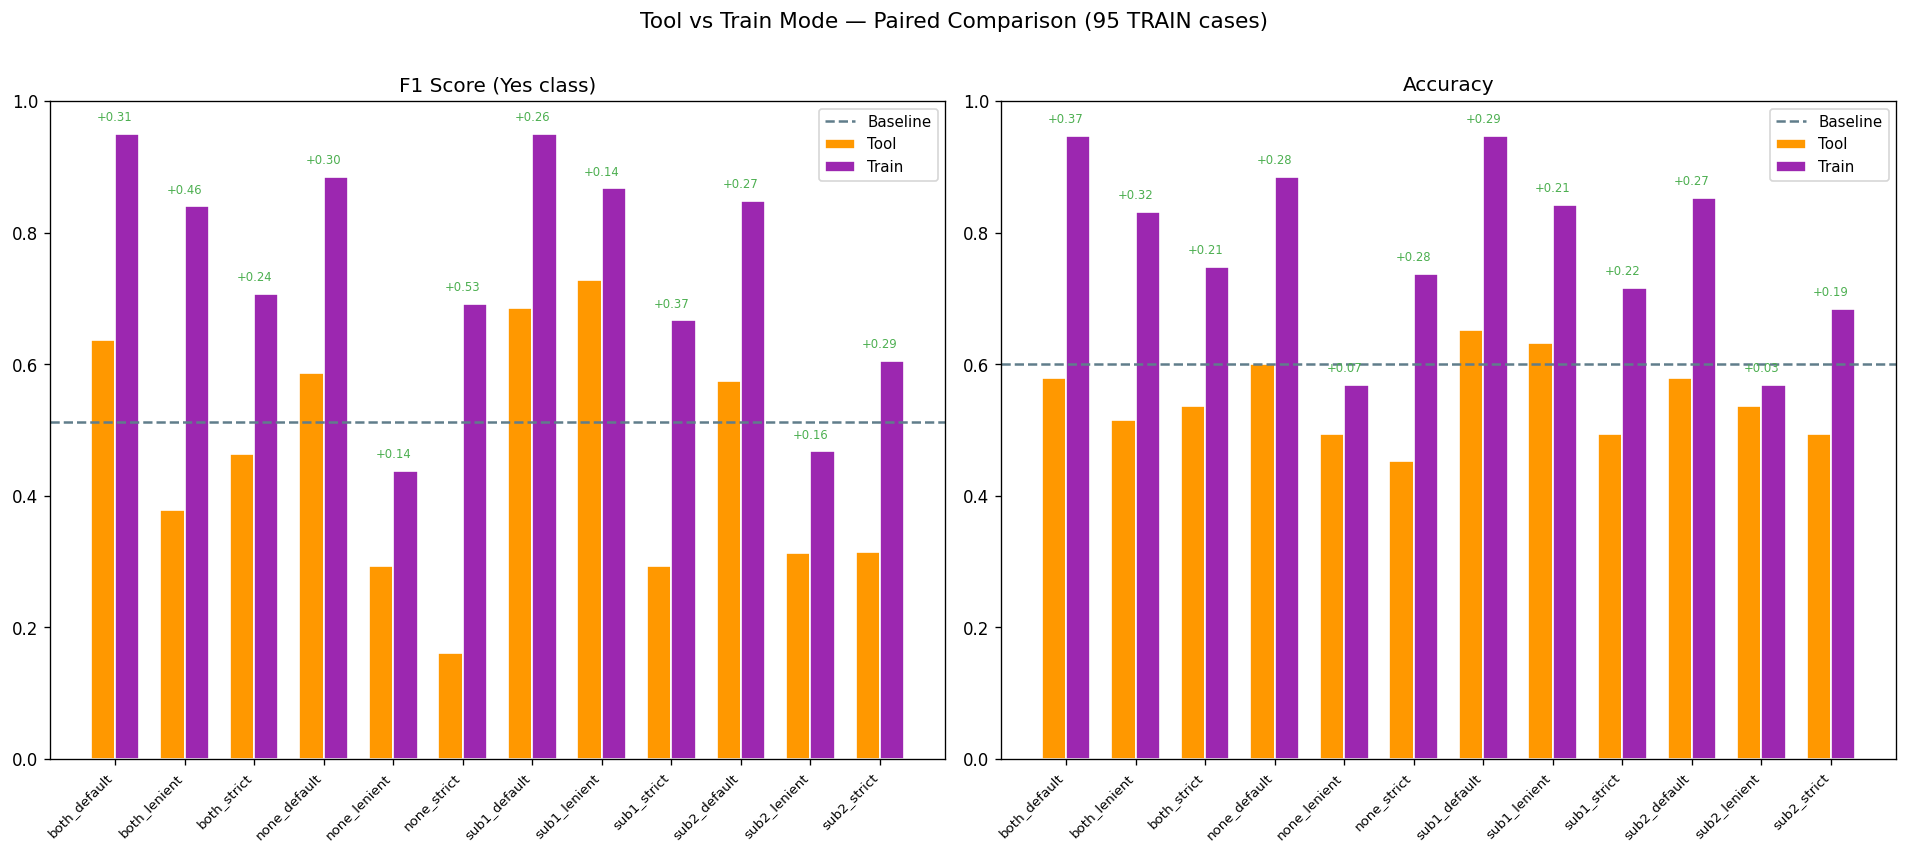

In [ ]:
available_models = metrics['model'].unique().tolist()
non_bl = metrics[metrics['run_mode'] != 'baseline'].copy()
bl_rows = metrics[metrics['run_mode'] == 'baseline'].copy()

# ── 4a. Tool vs Train paired comparison — one subplot per model ──────────────
for col, metric_title in [('f1', 'F1 Score (Yes class)'), ('accuracy', 'Accuracy')]:
    fig, axes = plt.subplots(1, len(available_models),
                             figsize=(9 * len(available_models), 7), sharey=True)
    if len(available_models) == 1:
        axes = [axes]
    for ax, model in zip(axes, available_models):
        tool_m  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
        train_m = non_bl[(non_bl['model']==model) & (non_bl['src']=='train')].set_index('config_key')
        paired_keys = sorted(set(tool_m.index) & set(train_m.index))
        if not paired_keys:
            ax.set_title(f'{model} — no paired data yet')
            continue
        x = np.arange(len(paired_keys)); w = 0.35
        tool_vals  = [tool_m.loc[k, col]  for k in paired_keys]
        train_vals = [train_m.loc[k, col] for k in paired_keys]
        tc = COMBO_COLORS.get((model, 'tool'),  '#FF9800')
        rc = COMBO_COLORS.get((model, 'train'), '#9C27B0')
        ax.bar(x - w/2, tool_vals,  w, label='Tool',  color=tc, edgecolor='white')
        ax.bar(x + w/2, train_vals, w, label='Train', color=rc, edgecolor='white')
        # baseline ref line
        bl = bl_rows[bl_rows['model'] == model]
        if len(bl):
            ax.axhline(bl.iloc[0][col], color=MODE_COLORS['baseline'],
                       ls='--', lw=1.5, label='Baseline')
        ax.set_xticks(x)
        ax.set_xticklabels(paired_keys, rotation=45, ha='right', fontsize=8)
        ax.set_ylim(0, 1); ax.set_title(f'{model}'); ax.legend(fontsize=9)
        for i, k in enumerate(paired_keys):
            delta = train_vals[i] - tool_vals[i]
            color = '#4CAF50' if delta > 0 else '#F44336'
            ax.text(i, max(tool_vals[i], train_vals[i]) + 0.02,
                    f'{delta:+.2f}', ha='center', fontsize=7, color=color)
    plt.suptitle(f'Tool vs Train — {metric_title} (95 TRAIN cases)', fontsize=13, y=1.01)
    plt.tight_layout(); plt.show()

# ── 4b. Cross-model comparison of best tool config per model ─────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in [(axes[0], 'f1', 'F1'), (axes[1], 'accuracy', 'Accuracy')]:
    for model in available_models:
        tool_m = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
        if tool_m.empty: continue
        vals = tool_m[col].sort_index().values
        keys = list(tool_m[col].sort_index().index)
        ax.plot(range(len(keys)), vals, marker='o', label=f'{model} tool',
                color=COMBO_COLORS.get((model,'tool'), '#333'))
        train_m = non_bl[(non_bl['model']==model) & (non_bl['src']=='train')].set_index('config_key')
        if not train_m.empty:
            tvals = [train_m.loc[k, col] if k in train_m.index else np.nan for k in keys]
            ax.plot(range(len(keys)), tvals, marker='s', ls='--', label=f'{model} train',
                    color=COMBO_COLORS.get((model,'train'), '#999'))
    ax.set_xticks(range(len(keys))); ax.set_xticklabels(keys, rotation=45, ha='right', fontsize=8)
    ax.set_ylim(0, 1); ax.set_ylabel(title); ax.set_title(f'{title} — all models')
    ax.legend(fontsize=8)
plt.suptitle('Cross-model comparison across all configs', fontsize=12)
plt.tight_layout(); plt.show()

## 5. Train–Tool Delta Table (per model)

How much does having the ground-truth reasoning in the prompt improve each configuration?

In [ ]:
delta_by_model = {}   # model → list of delta dicts

for model in available_models:
    tool_m  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
    train_m = non_bl[(non_bl['model']==model) & (non_bl['src']=='train')].set_index('config_key')
    paired_keys = sorted(set(tool_m.index) & set(train_m.index))
    delta_rows = []
    for k in paired_keys:
        t = tool_m.loc[k]; r = train_m.loc[k]
        delta_rows.append({
            'model': model, 'config': k,
            'adm_config': t['adm_config'], 'questions': t['questions'],
            'tool_f1': t['f1'], 'train_f1': r['f1'], 'Δf1': r['f1'] - t['f1'],
            'tool_acc': t['accuracy'], 'train_acc': r['accuracy'], 'Δacc': r['accuracy'] - t['accuracy'],
            'tool_prec': t['precision'], 'train_prec': r['precision'], 'Δprec': r['precision'] - t['precision'],
            'tool_rec': t['recall'], 'train_rec': r['recall'], 'Δrec': r['recall'] - t['recall'],
        })
    delta_by_model[model] = delta_rows
    if delta_rows:
        print(f'\n── {model} ──────────────────────────────────────────')
        df = pd.DataFrame(delta_rows).sort_values('Δf1', ascending=False)
        display(df.style.format({
            'tool_f1':'{:.2f}','train_f1':'{:.2f}','Δf1':'{:+.2f}',
            'tool_acc':'{:.1%}','train_acc':'{:.1%}','Δacc':'{:+.1%}',
            'tool_prec':'{:.2f}','train_prec':'{:.2f}','Δprec':'{:+.2f}',
            'tool_rec':'{:.2f}','train_rec':'{:.2f}','Δrec':'{:+.2f}',
        }).background_gradient(subset=['Δf1','Δacc'], cmap='RdYlGn', vmin=-0.3, vmax=0.3))
    else:
        print(f'{model}: paired data not yet available (train results pending?)')

,config,adm_config,questions,tool_f1,train_f1,Δf1,tool_acc,train_acc,Δacc,tool_prec,train_prec,Δprec,tool_rec,train_rec,Δrec
5,none_strict,none,strict,0.16,0.69,+0.53,45.3%,73.7%,+28.4%,0.56,1.00,+0.44,0.09,0.53,+0.43
1,both_lenient,both,lenient,0.38,0.84,+0.46,51.6%,83.2%,+31.6%,0.67,0.89,+0.23,0.26,0.79,+0.53
8,sub1_strict,sub1,strict,0.29,0.67,+0.37,49.5%,71.6%,+22.1%,0.67,0.96,+0.30,0.19,0.51,+0.32
0,both_default,both,default,0.64,0.95,+0.31,57.9%,94.7%,+36.8%,0.61,1.00,+0.39,0.66,0.91,+0.25
3,none_default,none,default,0.59,0.88,+0.30,60.0%,88.4%,+28.4%,0.69,1.00,+0.31,0.51,0.79,+0.28
11,sub2_strict,sub2,strict,0.31,0.61,+0.29,49.5%,68.4%,+18.9%,0.65,1.00,+0.35,0.21,0.43,+0.23
9,sub2_default,sub2,default,0.57,0.85,+0.27,57.9%,85.3%,+27.4%,0.66,1.00,+0.34,0.51,0.74,+0.23
6,sub1_default,sub1,default,0.69,0.95,+0.26,65.3%,94.7%,+29.5%,0.69,1.00,+0.31,0.68,0.91,+0.23
2,both_strict,both,strict,0.46,0.71,+0.24,53.7%,74.7%,+21.1%,0.66,1.00,+0.34,0.36,0.55,+0.19
10,sub2_lenient,sub2,lenient,0.31,0.47,+0.16,53.7%,56.8%,+3.2%,0.91,0.75,-0.16,0.19,0.34,+0.15


## 6. Average Improvement by ADM Config & Question Type

Which ADM configurations and question framings benefit most from oracle guidance?

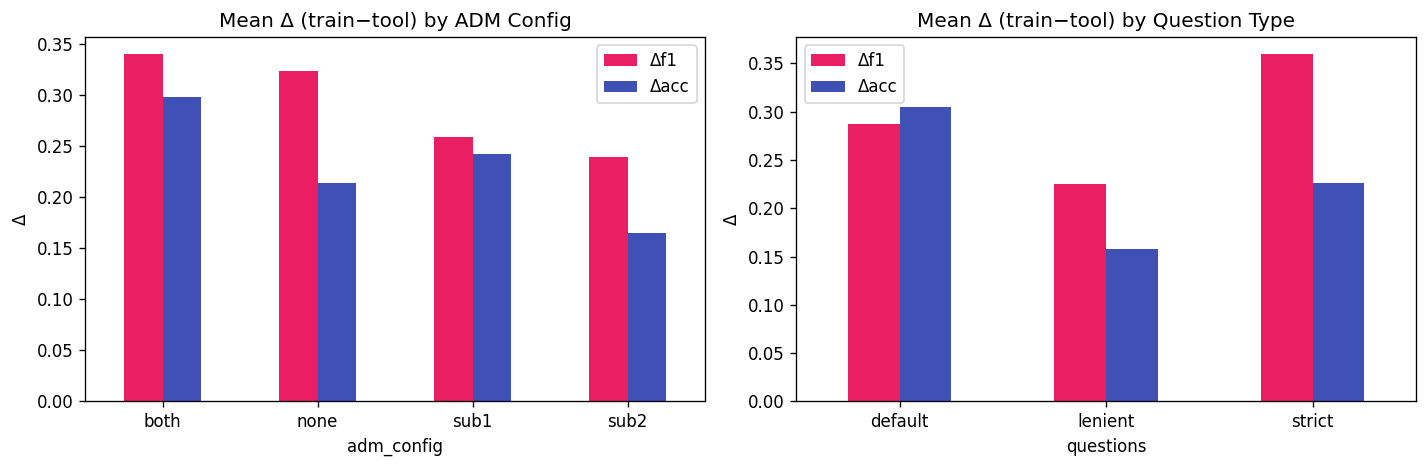

By ADM config:


,Δf1,Δacc
adm_config,,
both,0.340,0.298
none,0.324,0.214
sub1,0.259,0.242
sub2,0.240,0.165



By Question type:


,Δf1,Δacc
questions,,
default,0.287,0.305
lenient,0.225,0.158
strict,0.359,0.226


In [ ]:
for model in available_models:
    delta_rows = delta_by_model.get(model, [])
    if not delta_rows:
        print(f'{model}: no paired data yet'); continue
    ddf = pd.DataFrame(delta_rows)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grp_adm = ddf.groupby('adm_config')[['Δf1','Δacc']].mean()
    grp_adm.plot(kind='bar', ax=axes[0], color=['#E91E63','#3F51B5'])
    axes[0].set_title(f'{model} — Mean Δ (train−tool) by ADM Config')
    axes[0].set_ylabel('Δ'); axes[0].tick_params(axis='x', rotation=0)
    axes[0].axhline(0, color='black', lw=0.5)
    grp_q = ddf.groupby('questions')[['Δf1','Δacc']].mean()
    grp_q.plot(kind='bar', ax=axes[1], color=['#E91E63','#3F51B5'])
    axes[1].set_title(f'{model} — Mean Δ (train−tool) by Question Type')
    axes[1].set_ylabel('Δ'); axes[1].tick_params(axis='x', rotation=0)
    axes[1].axhline(0, color='black', lw=0.5)
    plt.tight_layout(); plt.show()
    print(f'{model} — By ADM config:'); display(grp_adm.round(3))
    print(f'{model} — By Question type:'); display(grp_q.round(3))

## 7. Confusion Matrices — Best ADM Config (Tool vs Train, per model)

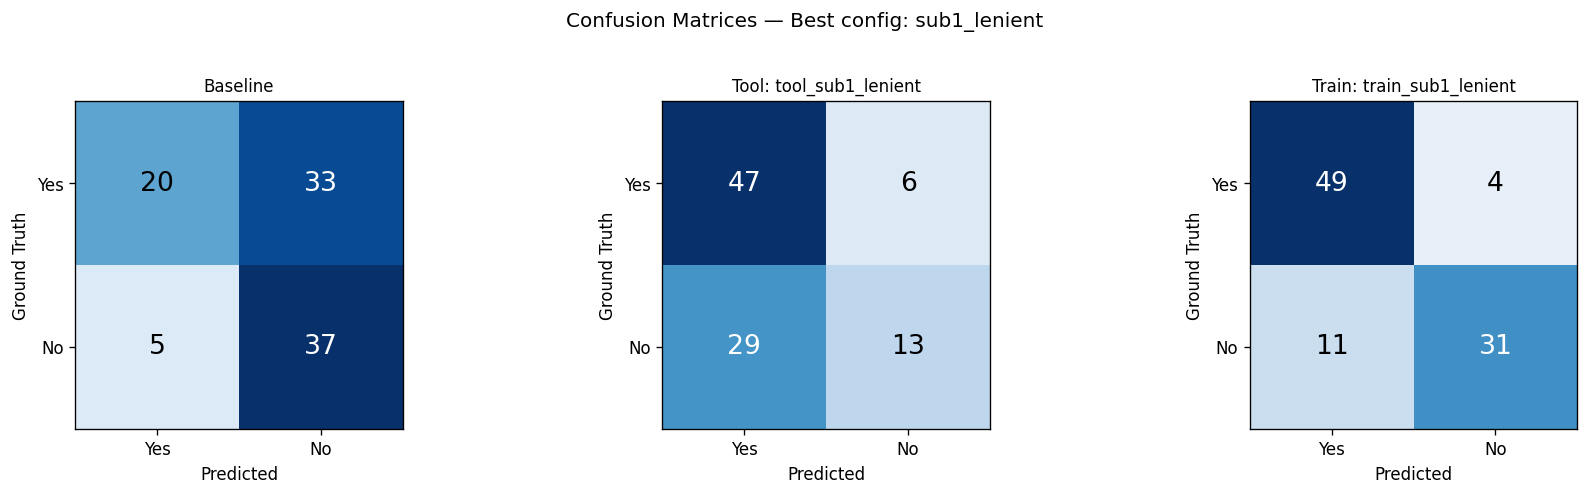

In [ ]:
def plot_cm(preds, gt, title, ax):
    cm = Counter()
    for cid, p in preds.items():
        t = gt.get(cid)
        if t and t != 'MISSING' and p in ('Yes','No'):
            cm[(t, p)] += 1
    labels = ['Yes','No']
    mat = [[cm.get((t,p),0) for p in labels] for t in labels]
    ax.imshow(mat, cmap='Blues', vmin=0)
    ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(labels); ax.set_yticklabels(labels)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
    ax.set_title(title, fontsize=9)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(mat[i][j]), ha='center', va='center',
                    fontsize=16, color='white' if mat[i][j] > 20 else 'black')

for model in available_models:
    model_preds = {k: v for (m, k), v in all_preds.items() if m == model}
    tool_p  = model_preds.get('tool',  {})
    train_p = model_preds.get('train', {})
    if not tool_p:
        print(f'{model}: no tool predictions yet'); continue

    nb_tool  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')]
    best_tool_row = nb_tool.sort_values('f1', ascending=False).iloc[0] if len(nb_tool) else None
    best_key = best_tool_row['config_key'] if best_tool_row is not None else None
    best_tool_name = best_tool_row['experiment'] if best_tool_row is not None else None

    # Find matching train experiment
    best_train_name = None
    if train_p and best_key:
        candidates = [n for n in train_p if
                      n.replace('train_','') == best_key or n == 'train_' + best_key]
        best_train_name = candidates[0] if candidates else None

    bl_name = next((n for n in tool_p if 'baseline' in n), None)
    panels = [(f'Baseline ({model})', tool_p.get(bl_name, {}))]
    if best_tool_name:
        panels.append((f'Tool best:\n{best_tool_name}', tool_p.get(best_tool_name, {})))
    if best_train_name:
        panels.append((f'Train best:\n{best_train_name}', train_p.get(best_train_name, {})))

    fig, axes = plt.subplots(1, len(panels), figsize=(5*len(panels), 4))
    if len(panels) == 1: axes = [axes]
    for ax, (title, preds) in zip(axes, panels):
        plot_cm(preds, gt_train, title, ax)
    plt.suptitle(f'{model} — Confusion Matrices (best config: {best_key})', y=1.02)
    plt.tight_layout(); plt.show()

## 8. Per-Case Diagnosis — Where Tool Fails but Train Succeeds

These are cases where the LLM gets the answer **right** with oracle guidance but **wrong** without it. This is the "ADM gap" — the ADM's question-answering isn't guiding the LLM to the correct factors.

In [ ]:
gap_cases_by_model = {}   # model → {config_key: list of (cid, tool_pred, train_pred, truth)}

for model in available_models:
    tool_p  = all_preds.get((model, 'tool'),  {})
    train_p = all_preds.get((model, 'train'), {})
    if not tool_p or not train_p:
        print(f'{model}: tool/train not both available — skipping gap analysis')
        gap_cases_by_model[model] = {}
        continue

    tool_m_idx  = non_bl[(non_bl['model']==model) & (non_bl['src']=='tool')].set_index('config_key')
    paired_keys = sorted(set(tool_m_idx.index) &
                         set(non_bl[(non_bl['model']==model) & (non_bl['src']=='train')]['config_key']))
    gap_cases = {}
    for k in paired_keys:
        tool_exp  = [n for n in tool_p  if n.replace('tool_','')  == k or n == 'tool_'+k]
        train_exp = [n for n in train_p if n.replace('train_','') == k or n == 'train_'+k]
        if not tool_exp or not train_exp: continue
        tp = tool_p[tool_exp[0]]; rp = train_p[train_exp[0]]
        gaps = []
        for cid in train_cases:
            truth = gt_train.get(cid)
            if truth and truth != 'MISSING':
                if tp.get(cid) != truth and rp.get(cid) == truth:
                    gaps.append((cid, tp.get(cid), rp.get(cid), truth))
        gap_cases[k] = gaps
    gap_cases_by_model[model] = gap_cases

    gap_counter = Counter()
    for k, gaps in gap_cases.items():
        for cid, _, _, _ in gaps: gap_counter[cid] += 1

    print(f'\n── {model} ── Cases where TRAIN correct but TOOL wrong ──')
    for k in paired_keys:
        g = gap_cases.get(k, [])
        print(f'  {k:30s}: {len(g)} gap cases')
    print(f'\nTop 10 most frequent gap cases ({model}):')
    for cid, count in gap_counter.most_common(10):
        print(f'  {cid}: gap in {count}/{len(paired_keys)} configs (truth={gt_train[cid]})')

Cases where TRAIN correct but TOOL wrong (per config):
  both_default                  : 38 gap cases
  both_lenient                  : 37 gap cases
  both_strict                   : 30 gap cases
  none_default                  : 33 gap cases
  none_lenient                  : 17 gap cases
  none_strict                   : 28 gap cases
  sub1_default                  : 30 gap cases
  sub1_lenient                  : 26 gap cases
  sub1_strict                   : 26 gap cases
  sub2_default                  : 30 gap cases
  sub2_lenient                  : 16 gap cases
  sub2_strict                   : 23 gap cases

--- Most frequent gap cases (across all 12 configs) ---
  T078811: gap in 8/12 configs (truth=Yes)
  T112211: gap in 8/12 configs (truth=Yes)
  T184111: gap in 8/12 configs (truth=No)
  T190310: gap in 8/12 configs (truth=Yes)
  T007714: gap in 7/12 configs (truth=Yes)
  T052011: gap in 7/12 configs (truth=Yes)
  T071810: gap in 7/12 configs (truth=Yes)
  T077614: gap in 7/12 c

## 9. Gap Analysis — Error Direction

When tool mode fails on cases that train gets right, which direction is the error?
- **FN gap** (tool says No, truth is Yes) = tool is too conservative / misses inventive step
- **FP gap** (tool says Yes, truth is No) = tool is too generous / hallucinating inventive step

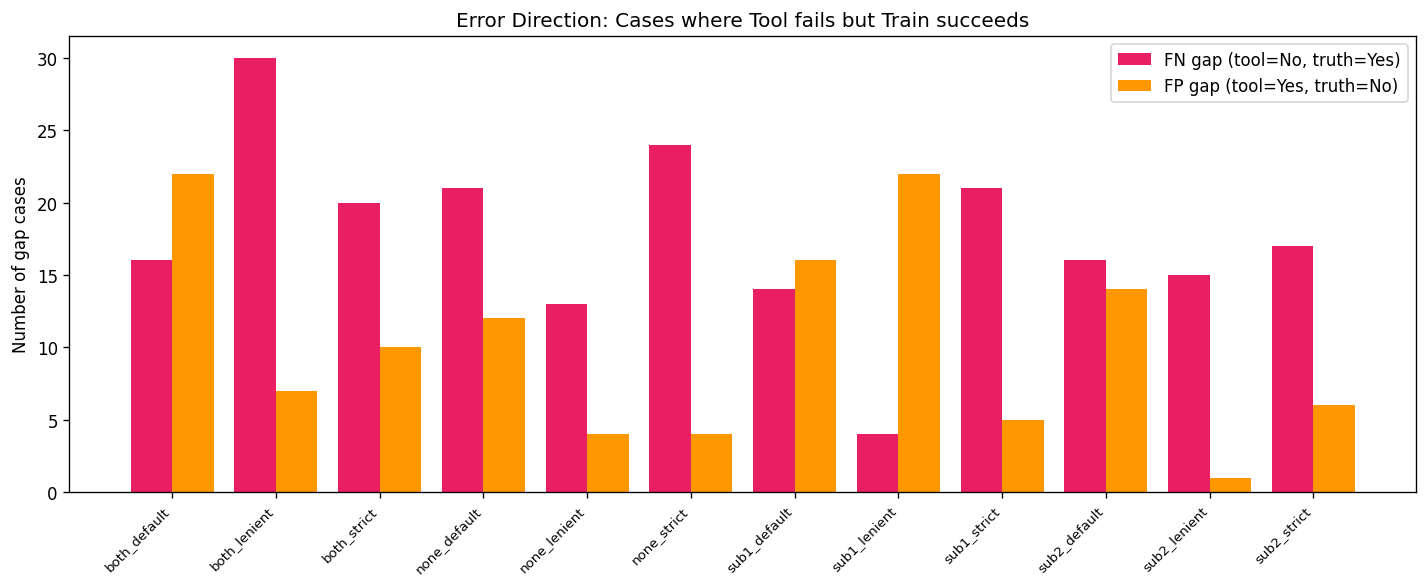


Total across all configs: 211 FN gaps (conservative), 123 FP gaps (generous)
Ratio: 63% of gaps are conservative errors (tool misses inventive step)


In [ ]:
total_fn_by_model = {}
total_fp_by_model = {}

for model in available_models:
    gap_cases = gap_cases_by_model.get(model, {})
    if not gap_cases:
        total_fn_by_model[model] = 0; total_fp_by_model[model] = 0; continue
    paired_keys = sorted(gap_cases.keys())
    err_rows = []
    for k in paired_keys:
        gaps = gap_cases.get(k, [])
        fn_gaps = sum(1 for _, tp, _, tr in gaps if tr == 'Yes' and tp == 'No')
        fp_gaps = sum(1 for _, tp, _, tr in gaps if tr == 'No'  and tp == 'Yes')
        err_rows.append({'config': k, 'FN_gaps': fn_gaps, 'FP_gaps': fp_gaps,
                         'total_gaps': fn_gaps+fp_gaps})
    err_df = pd.DataFrame(err_rows)
    total_fn = err_df['FN_gaps'].sum(); total_fp = err_df['FP_gaps'].sum()
    total_fn_by_model[model] = total_fn; total_fp_by_model[model] = total_fp

    fig, ax = plt.subplots(figsize=(12, 4))
    x = np.arange(len(err_df))
    ax.bar(x - 0.2, err_df['FN_gaps'], 0.4, label='FN gap (tool=No, truth=Yes)', color='#E91E63')
    ax.bar(x + 0.2, err_df['FP_gaps'], 0.4, label='FP gap (tool=Yes, truth=No)', color='#FF9800')
    ax.set_xticks(x); ax.set_xticklabels(err_df['config'], rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Number of gap cases')
    ax.set_title(f'{model} — Error direction: cases where Tool fails but Train succeeds')
    ax.legend(); plt.tight_layout(); plt.show()
    if total_fn + total_fp > 0:
        print(f'{model}: {total_fn} FN gaps, {total_fp} FP gaps — '
              f'{total_fn/(total_fn+total_fp):.0%} conservative')

## 10. Prediction Heatmap — Tool vs Train per Model (all experiments × cases)

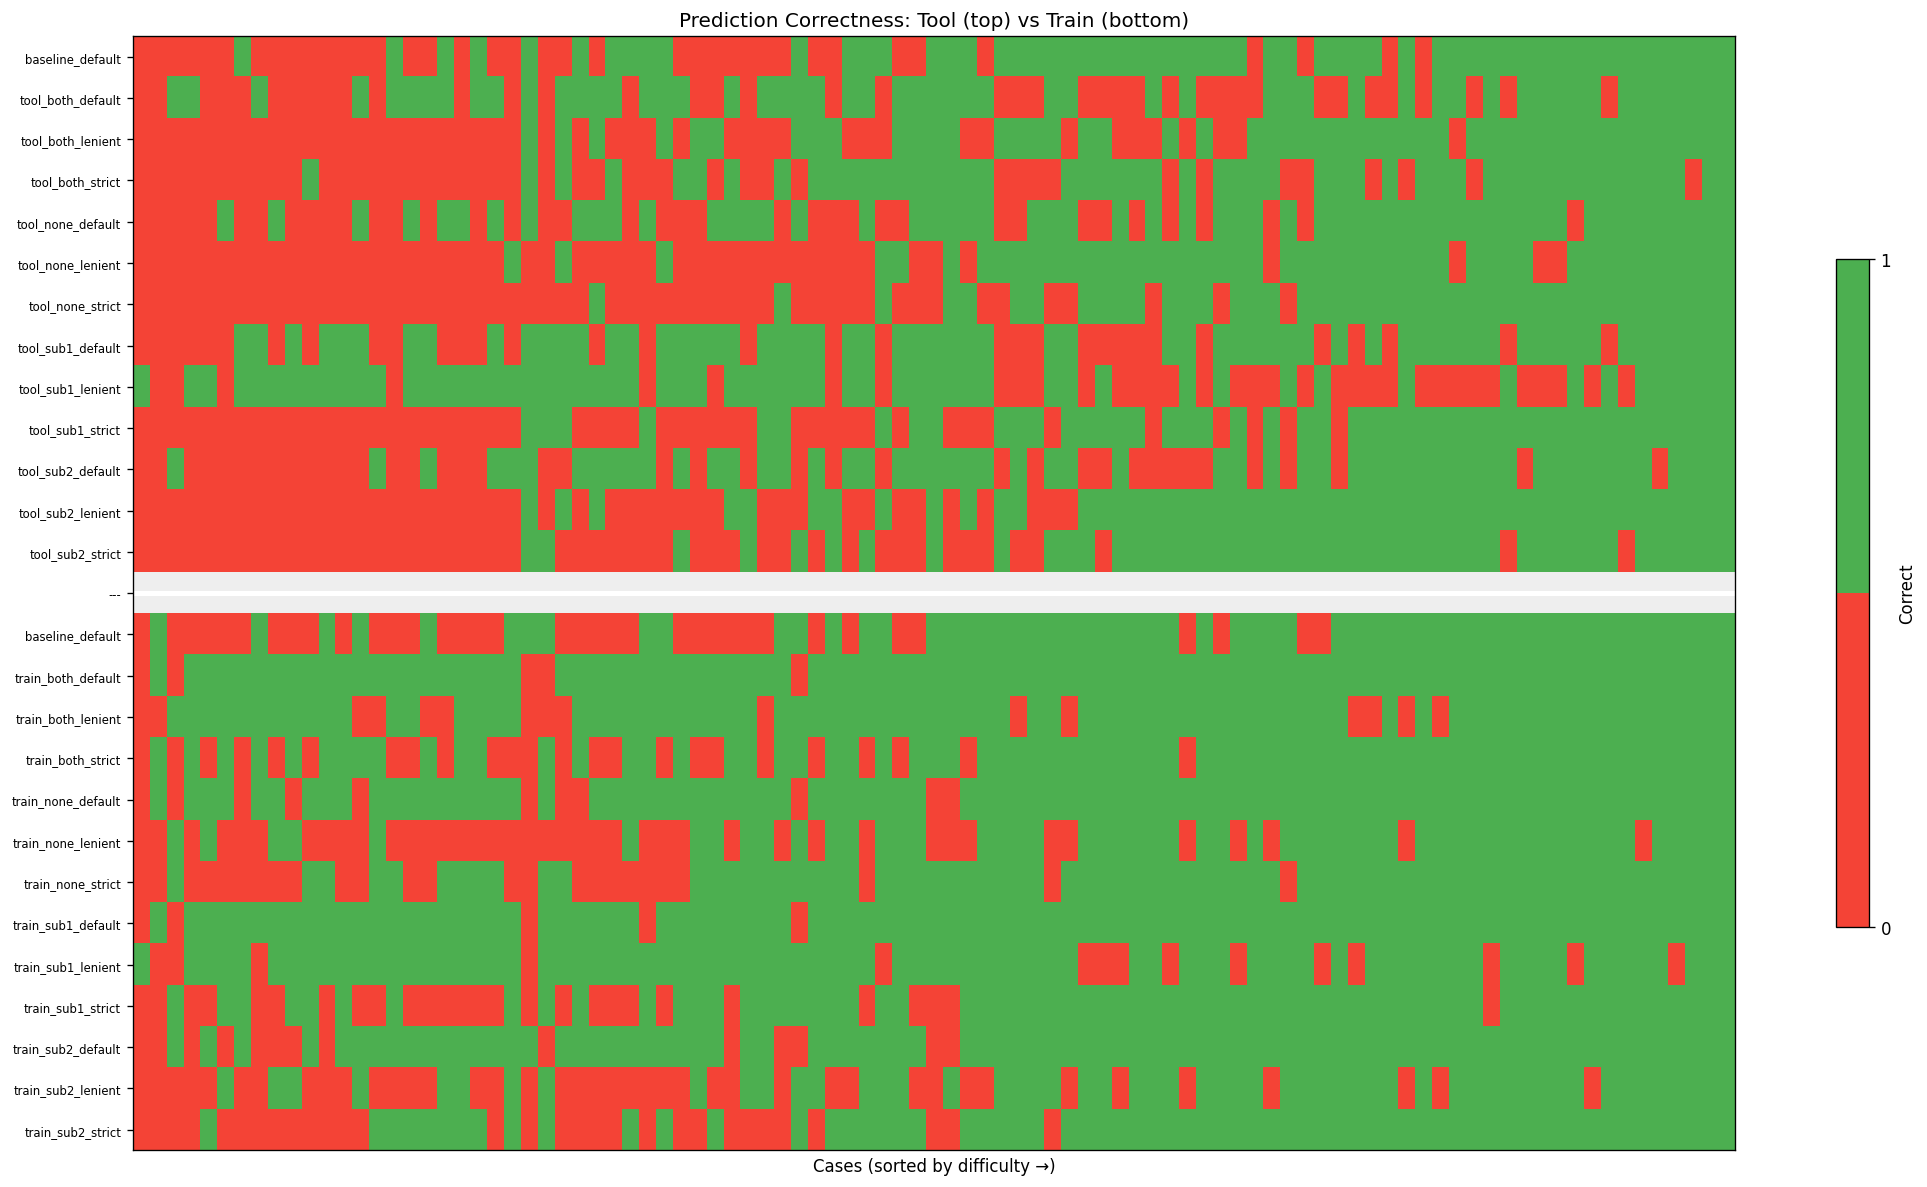

In [ ]:
# Sort cases by overall difficulty (fraction correct across ALL experiments)
all_combined_flat = {f'{m}_{s}_{n}': p
                     for (m, s), exps in all_preds.items()
                     for n, p in exps.items()}
case_correct_all = {c: 0 for c in train_cases}
case_total_all   = {c: 0 for c in train_cases}
for preds in all_combined_flat.values():
    for cid, pred in preds.items():
        if cid in gt_train and gt_train[cid] != 'MISSING' and pred in ('Yes','No'):
            case_total_all[cid] += 1
            if pred == gt_train[cid]: case_correct_all[cid] += 1
case_frac  = {c: case_correct_all[c]/case_total_all[c] if case_total_all[c] else 0
              for c in train_cases}
sorted_cases = sorted(train_cases, key=lambda c: case_frac[c])

cmap = matplotlib.colors.ListedColormap(['#F44336', '#4CAF50'])
cmap.set_bad('#EEEEEE')

for model in available_models:
    tool_p  = all_preds.get((model, 'tool'),  {})
    train_p = all_preds.get((model, 'train'), {})
    if not tool_p:
        print(f'{model}: no tool predictions yet'); continue
    tool_names  = sorted(tool_p.keys())
    train_names = sorted(train_p.keys()) if train_p else []
    all_names   = tool_names + (['---'] if train_names else []) + train_names
    nrows = len(tool_names) + (1 if train_names else 0) + len(train_names)
    matrix = np.full((nrows, len(sorted_cases)), np.nan)
    for i, exp in enumerate(tool_names):
        for j, c in enumerate(sorted_cases):
            p = tool_p[exp].get(c); t = gt_train.get(c)
            if p and t and t != 'MISSING' and p in ('Yes','No'):
                matrix[i, j] = 1.0 if p == t else 0.0
    if train_names:
        for i, exp in enumerate(train_names):
            for j, c in enumerate(sorted_cases):
                p = train_p[exp].get(c); t = gt_train.get(c)
                if p and t and t != 'MISSING' and p in ('Yes','No'):
                    matrix[len(tool_names)+1+i, j] = 1.0 if p == t else 0.0
    fig, ax = plt.subplots(figsize=(18, max(6, nrows * 0.55)))
    im = ax.imshow(matrix, cmap=cmap, aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    ax.set_yticks(range(len(all_names))); ax.set_yticklabels(all_names, fontsize=7)
    ax.set_xlabel('Cases (sorted by difficulty →)')
    ax.set_title(f'{model} — Prediction Correctness: Tool (top) vs Train (bottom)')
    ax.set_xticks([])
    if train_names:
        ax.axhline(len(tool_names) - 0.5 + 0.5, color='white', lw=3)
    plt.colorbar(im, ax=ax, ticks=[0,1], label='Correct', shrink=0.6)
    plt.tight_layout(); plt.show()

## 11. Timing Comparison

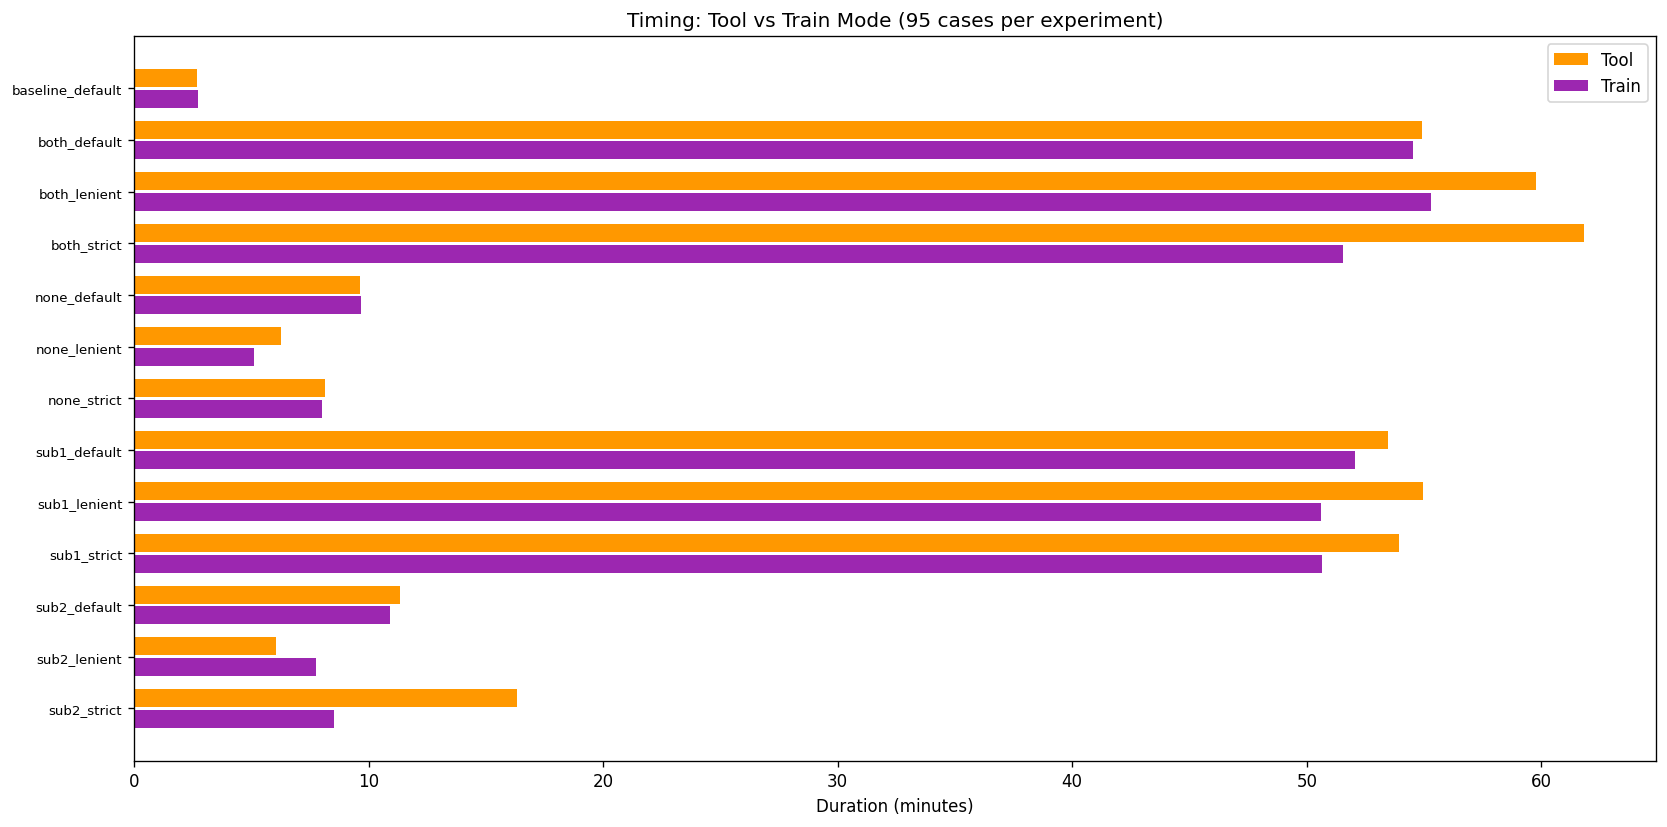

Tool total:  6.7 hours
Train total: 6.1 hours


In [ ]:
all_timing_frames = []
for model, dirs in MODELS.items():
    for src_label, src_dir in dirs.items():
        if not src_dir or not os.path.isdir(src_dir): continue
        path = os.path.join(src_dir, 'timing.csv')
        if not os.path.exists(path): continue
        df = pd.read_csv(path)
        df['model'] = model; df['src'] = src_label
        df['duration_min'] = df['duration_s'] / 60
        df['key'] = df['experiment'].str.replace(r'^(tool_|train_)', '', regex=True)
        all_timing_frames.append(df)

if not all_timing_frames:
    print('No timing data available yet.')
else:
    timing_all = pd.concat(all_timing_frames, ignore_index=True)

    # Bar chart: duration per experiment, grouped by model+src
    fig, ax = plt.subplots(figsize=(15, 6))
    combos = timing_all[['model','src']].drop_duplicates().values.tolist()
    common_keys = sorted(timing_all['key'].unique())
    n_combos = len(combos); w = 0.8 / n_combos
    x = np.arange(len(common_keys))
    for i, (model, src) in enumerate(combos):
        sub = timing_all[(timing_all['model']==model) & (timing_all['src']==src)]
        sub = sub.set_index('key')
        vals = [sub.loc[k, 'duration_min'] if k in sub.index else 0 for k in common_keys]
        color = COMBO_COLORS.get((model, src), '#aaa')
        ax.barh(x - (n_combos-1)*w/2 + i*w, vals, w,
                label=f'{model} {src}', color=color)
    ax.set_yticks(x); ax.set_yticklabels(common_keys, fontsize=8)
    ax.set_xlabel('Duration (minutes)')
    ax.set_title('Timing comparison — all models × modes (95 cases per experiment)')
    ax.legend(); ax.invert_yaxis()
    plt.tight_layout(); plt.show()

    # Summary
    print('\nTiming totals (hours):')
    for (model, src), grp in timing_all.groupby(['model','src']):
        print(f'  {model} {src}: {grp["duration_s"].sum()/3600:.1f} h  '
              f'({grp["duration_s"].mean()/60:.0f} min avg per experiment)')

## 12. Hardest Cases — Resistant to Both Modes

Cases that are wrong in **both** tool and train across the majority of configs point to fundamental ADM/data issues rather than prompt quality.

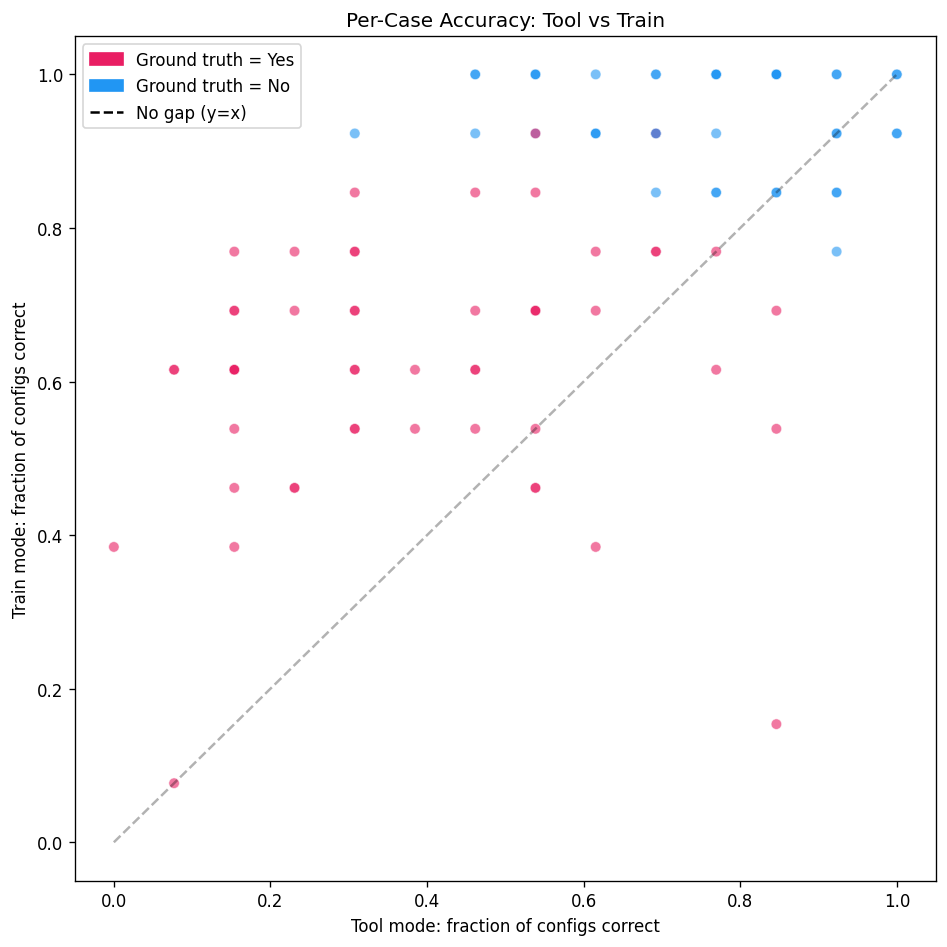


0 cases wrong in ALL experiments (both modes):

Top 15 hardest cases (≤15% correct across both modes):


,case,truth,tool_frac,train_frac,gap
78,T212310,Yes,8%,8%,+0%


In [ ]:
for model in available_models:
    tool_p  = all_preds.get((model, 'tool'),  {})
    train_p = all_preds.get((model, 'train'), {})
    if not tool_p:
        print(f'{model}: no tool data yet'); continue

    t_correct = {c: 0 for c in train_cases}; t_total = {c: 0 for c in train_cases}
    r_correct = {c: 0 for c in train_cases}; r_total  = {c: 0 for c in train_cases}
    for preds in tool_p.values():
        for cid, p in preds.items():
            if cid in gt_train and gt_train[cid] != 'MISSING' and p in ('Yes','No'):
                t_total[cid] += 1
                if p == gt_train[cid]: t_correct[cid] += 1
    for preds in (train_p or {}).values():
        for cid, p in preds.items():
            if cid in gt_train and gt_train[cid] != 'MISSING' and p in ('Yes','No'):
                r_total[cid] += 1
                if p == gt_train[cid]: r_correct[cid] += 1

    hard_rows = []
    for c in train_cases:
        tf = t_correct[c]/t_total[c] if t_total[c] else 0
        rf = r_correct[c]/r_total[c] if r_total[c] else 0
        hard_rows.append({'case': c, 'truth': gt_train[c],
                          'tool_frac': tf, 'train_frac': rf,
                          'both_frac': (tf + rf) / 2 if r_total[c] else tf,
                          'gap': rf - tf})
    hard_df = pd.DataFrame(hard_rows).sort_values('both_frac')

    fig, ax = plt.subplots(figsize=(7, 7))
    colors = ['#E91E63' if t == 'Yes' else '#2196F3' for t in hard_df['truth']]
    ax.scatter(hard_df['tool_frac'], hard_df['train_frac'], c=colors, alpha=0.6, s=40,
               edgecolors='white', lw=0.5)
    ax.plot([0,1],[0,1],'k--',alpha=0.3,label='y=x (no gap)')
    ax.set_xlabel('Tool mode: fraction correct'); ax.set_ylabel('Train mode: fraction correct')
    ax.set_title(f'{model} — Per-case accuracy: Tool vs Train')
    ax.legend([Patch(color='#E91E63'), Patch(color='#2196F3'),
               plt.Line2D([],[], color='k', ls='--')],
              ['truth=Yes','truth=No','No gap'], loc='upper left')
    ax.set_xlim(-0.05, 1.05); ax.set_ylim(-0.05, 1.05)
    plt.tight_layout(); plt.show()

    always_wrong = hard_df[hard_df['both_frac'] == 0]
    print(f'{model}: {len(always_wrong)} cases wrong in ALL experiments')
    mostly_wrong = hard_df[hard_df['both_frac'] <= 0.15].head(15)
    print(f'Top hardest (≤15% correct):')
    display(mostly_wrong[['case','truth','tool_frac','train_frac','gap']].style.format(
        {'tool_frac':'{:.0%}','train_frac':'{:.0%}','gap':'{:+.0%}'}
    ).background_gradient(subset=['gap'], cmap='RdYlGn', vmin=-0.5, vmax=0.5))

## 13. Summary & Diagnosis

In [ ]:
print('='*70)
print('LLM COMPARISON SUMMARY — TOOL vs TRAIN MODE')
print('='*70)
print(f'\nDataset: {len(train_cases)} TRAIN cases ({yes_count} Yes / {no_count} No)')
print(f'Majority-class baseline: {max(yes_count, no_count)/len(train_cases):.1%}')

for model in available_models:
    print(f'\n{"─"*60}')
    print(f'  MODEL: {model}')
    print(f'{"─"*60}')
    tool_m  = metrics[(metrics['model']==model) & (metrics['src']=='tool')  & (metrics['run_mode']!='baseline')]
    train_m = metrics[(metrics['model']==model) & (metrics['src']=='train') & (metrics['run_mode']!='baseline')]
    bl_m    = metrics[(metrics['model']==model) & (metrics['run_mode']=='baseline')]

    if len(tool_m):
        print(f'  Tool  ({len(tool_m)} configs): '
              f'F1={tool_m["f1"].mean():.3f}  Acc={tool_m["accuracy"].mean():.1%}  '
              f'Prec={tool_m["precision"].mean():.2f}  Rec={tool_m["recall"].mean():.2f}')
    else:
        print(f'  Tool: no data')
    if len(train_m):
        print(f'  Train ({len(train_m)} configs): '
              f'F1={train_m["f1"].mean():.3f}  Acc={train_m["accuracy"].mean():.1%}  '
              f'Prec={train_m["precision"].mean():.2f}  Rec={train_m["recall"].mean():.2f}')
    else:
        print(f'  Train: no data yet')
    if len(bl_m):
        b = bl_m.iloc[0]
        print(f'  Baseline:           '
              f'F1={b["f1"]:.3f}  Acc={b["accuracy"]:.1%}  '
              f'Prec={b["precision"]:.2f}  Rec={b["recall"]:.2f}')

    if len(tool_m) and len(train_m):
        δf1  = train_m['f1'].mean()       - tool_m['f1'].mean()
        δacc = train_m['accuracy'].mean() - tool_m['accuracy'].mean()
        print(f'  Mean Δ (train−tool): ΔF1={δf1:+.3f}  ΔAcc={δacc:+.1%}')

    if len(tool_m):
        best_t = tool_m.sort_values('f1', ascending=False).iloc[0]
        print(f'  Best tool:  {best_t["experiment"]}  F1={best_t["f1"]:.2f}')
    if len(train_m):
        best_r = train_m.sort_values('f1', ascending=False).iloc[0]
        print(f'  Best train: {best_r["experiment"]}  F1={best_r["f1"]:.2f}')

    fn = total_fn_by_model.get(model, 0); fp = total_fp_by_model.get(model, 0)
    if fn + fp > 0:
        print(f'  Gap errors: {fn} FN (conservative) / {fp} FP (generous) — '
              f'{fn/(fn+fp):.0%} conservative')

# ── Cross-model comparison table ─────────────────────────────────────────────
print(f'\n{"─"*60}')
print('  CROSS-MODEL TOOL COMPARISON (avg F1 across 12 non-baseline configs)')
print(f'{"─"*60}')
for model in available_models:
    tool_m = metrics[(metrics['model']==model) & (metrics['src']=='tool') & (metrics['run_mode']!='baseline')]
    if len(tool_m):
        print(f'  {model:10s}: F1={tool_m["f1"].mean():.3f}  '
              f'best={tool_m.sort_values("f1",ascending=False).iloc[0]["experiment"]}  '
              f'F1={tool_m.sort_values("f1",ascending=False).iloc[0]["f1"]:.2f}')

GPT-OSS-120B — TOOL vs TRAIN MODE SUMMARY

Dataset: 95 TRAIN cases (53 Yes / 42 No)
Majority-class baseline: 55.8%

--- Overall Averages (12 configs each) ---
  Tool:     F1=0.453  Acc=54.7%  Prec=0.67  Rec=0.39
  Train:    F1=0.743  Acc=77.7%  Prec=0.94  Rec=0.64
  Baseline: F1=0.513  Acc=60.0%  Prec=0.80  Rec=0.38

--- Mean Delta (train − tool) ---
  ΔF1:  +0.291
  ΔAcc: +23.0%
  ΔPrec: +0.265
  ΔRec:  +0.248

--- Best Configs ---
  Tool best:  tool_sub1_lenient  F1=0.73  Acc=63.2%
  Train best: train_both_default F1=0.95  Acc=94.7%

--- Diagnosis ---
  Total FN gaps (tool conservative): 211
  Total FP gaps (tool generous):     123
  Conservative error ratio: 63%
  → Tool mode's dominant failure pattern: CONSERVATIVE (predicts No when it should be Yes)

--- Timing ---
  Tool total:  6.7 hours
  Train total: 6.1 hours
